# Importing Packages

In [1]:
# ---------------------------
# Core Libraries
# ---------------------------
import os
import re
import string
import joblib
import numpy as np
import pandas as pd

# ---------------------------
# Visualization
# ---------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.special import expit  # sigmoid
# ---------------------------
# NLP Libraries
# ---------------------------
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.util import ngrams
from wordcloud import WordCloud

# ---------------------------
# Machine Learning
# ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from lightgbm import LGBMClassifier
from sklearn.neighbors import RadiusNeighborsClassifier, KNeighborsClassifier

# ---------------------------
# Utilities
# ---------------------------
from tqdm import tqdm
from imblearn.over_sampling import SMOTE



In [2]:
MODEL_DIR = "model"
RESULT_DIR = "results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

In [3]:
# NLTK downloads
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pavani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pavani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Pavani\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Pavani\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

## Dataset Loading

In [4]:
import pandas as pd
df = pd.read_csv(r"dataset/training.1600000.processed.noemoticon.csv",encoding="latin-1")
df.head()


,Target,Text
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew


In [5]:
df

,Target,Text
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew
...,...,...
11159,4,happy 16th too me... Got a macbook :O
11160,4,@followgenerator You ask: &quot;Which app is t...
11161,4,@mayorsam Hey u!! Where have you been hiding? ...
11162,4,@naughtymutt I could drop a bomb in here and n...


## Dataset Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11164 entries, 0 to 11163
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Target  11164 non-null  int64 
 1   Text    11164 non-null  object
dtypes: int64(1), object(1)
memory usage: 174.6+ KB


In [7]:
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [8]:
categories = df["Target"].unique()
y=df['Target']
categories = ["Negative","Positive"]

## EDA

In [9]:
def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Ensure iterable of strings
    X_text = list(X_text)

    # Flatten all tokens
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)

    wc = WordCloud(
    width=800,
    height=400,
    max_words=num_words,
    background_color="white").generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(np.array(wc.to_image()), interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(min(top_n_words, len(word_freq)))
    words, counts = zip(*common_words)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]

    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color="teal")
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)

    bigram_labels = [" ".join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


Generating NLP EDA Visualizations...


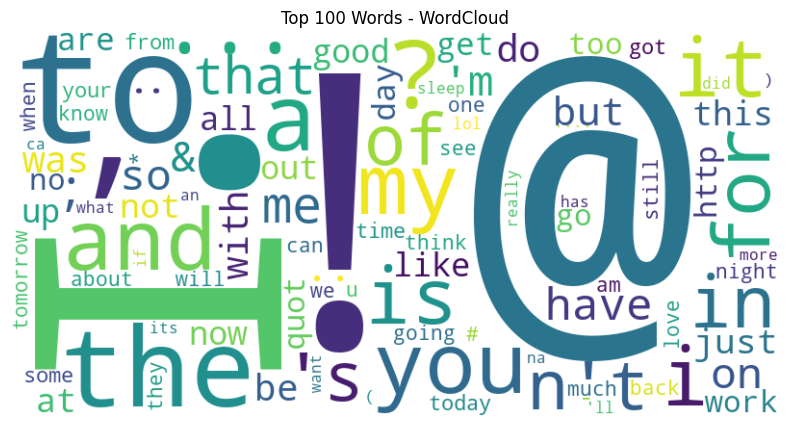

C:\Users\Pavani\AppData\Local\Temp\ipykernel_30916\3339749747.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


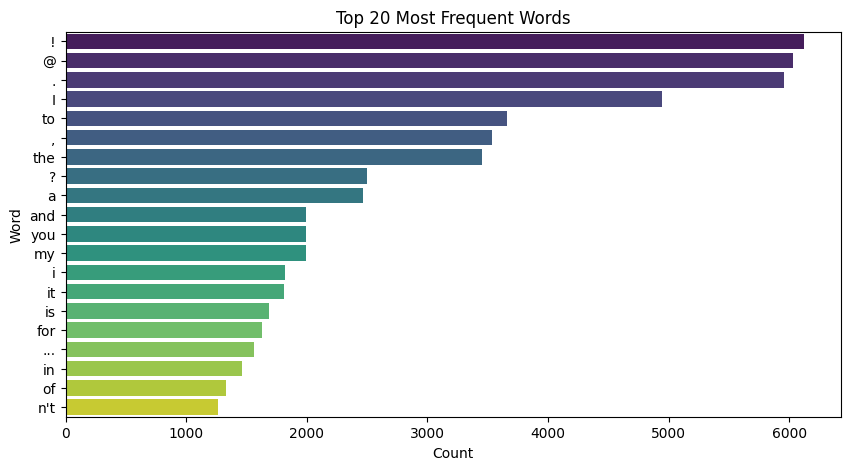

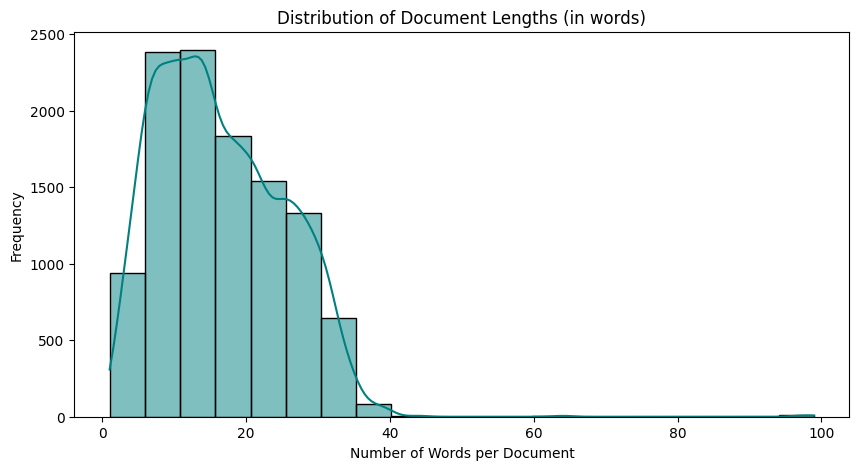

C:\Users\Pavani\AppData\Local\Temp\ipykernel_30916\3339749747.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")


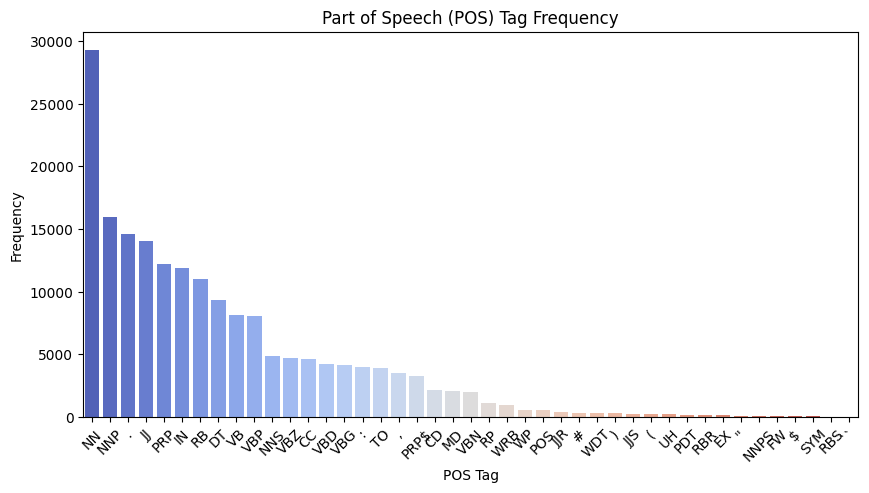

C:\Users\Pavani\AppData\Local\Temp\ipykernel_30916\3339749747.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")


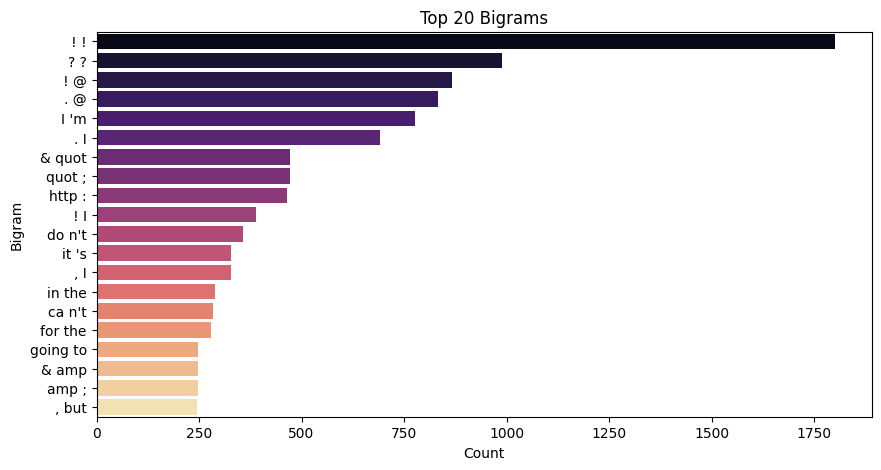

In [10]:
eda_nlp_analysis(X_text=df["Text"], num_words=100, top_n_words=20)

## NLP Preprocessing

In [11]:

# ---------------------------
# tqdm Integration
# ---------------------------
tqdm.pandas(desc="Text Preprocessing")

# ---------------------------
# Initializations
# ---------------------------
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# ---------------------------
# Preprocessing Function
# ---------------------------
def preprocess_text_full(text):

    # Step 1: Basic Cleaning
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9' ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenization
    tokens = word_tokenize(text)

    # POS tagging
    pos_tags = pos_tag(tokens)

    # POS Mapping
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return wordnet.ADJ
        elif tag.startswith('V'):
            return wordnet.VERB
        elif tag.startswith('N'):
            return wordnet.NOUN
        elif tag.startswith('R'):
            return wordnet.ADV
        return wordnet.NOUN

    # Lemmatization + Stopword Removal
    lemmas = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
        if word not in stop_words and word.strip() != ""
    ]

    return " ".join(lemmas)

In [12]:
df["clean_tweet"] = df["Text"].progress_apply(preprocess_text_full)

Text Preprocessing: 100%|███████████████████████████████████████████████████████| 11164/11164 [00:30<00:00, 364.10it/s]


In [13]:
df.drop(columns=["Text"], inplace=True)

In [14]:
df

,Target,clean_tweet
0,0,upset cant update facebook texting might cry r...
1,0,kenichan dive many time ball manage save 50 re...
2,0,whole body feel itchy like fire
3,0,nationwideclass behave im mad cant see
4,0,kwesidei whole crew
...,...,...
11159,4,happy 16th get macbook
11160,4,followgenerator ask quot app best acquire targ...
11161,4,mayorsam hey u hide thanks followfriday love
11162,4,naughtymutt could drop bomb nobody would wake


In [15]:
import numpy as np

def extract_text_features(text):
    tokens = text.split()

    if len(tokens) == 0:
        return pd.Series([0]*10)

    return pd.Series([
        len(tokens),                                      # word count
        len(text),                                        # char count
        np.mean([len(w) for w in tokens]),                # avg word length
        np.std([len(w) for w in tokens]),                 # std word length
        sum(w.isupper() for w in tokens),                 # uppercase words
        sum(any(c.isdigit() for c in w) for w in tokens), # digit words
        sum(w.isalpha() for w in tokens),                 # alphabetic words
        len(set(tokens)),                                 # unique words
        len(set(tokens)) / len(tokens),                   # lexical diversity
        sum(len(w) > 6 for w in tokens)                   # long words
    ])

stat_features = df["clean_tweet"].progress_apply(extract_text_features)
stat_features.columns = [
    "word_count", "char_count", "avg_word_len", "std_word_len",
    "upper_words", "digit_words", "alpha_words",
    "unique_words", "lexical_diversity", "long_words"
]


Text Preprocessing: 100%|██████████████████████████████████████████████████████| 11164/11164 [00:06<00:00, 1602.46it/s]


In [16]:
stat_features

,word_count,char_count,avg_word_len,std_word_len,upper_words,digit_words,alpha_words,unique_words,lexical_diversity,long_words
0,12.0,74.0,5.250000,1.361678,0.0,0.0,12.0,12.0,1.000000,2.0
1,11.0,57.0,4.272727,1.600620,0.0,1.0,10.0,11.0,1.000000,1.0
2,6.0,31.0,4.333333,0.471405,0.0,0.0,6.0,6.0,1.000000,0.0
3,6.0,38.0,5.500000,4.425306,0.0,0.0,6.0,6.0,1.000000,1.0
4,3.0,19.0,5.666667,1.699673,0.0,0.0,3.0,3.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...
11159,4.0,22.0,4.750000,1.479020,0.0,1.0,3.0,4.0,1.000000,1.0
11160,14.0,99.0,6.142857,3.181580,0.0,0.0,14.0,12.0,0.857143,6.0
11161,7.0,44.0,5.428571,3.374575,0.0,0.0,7.0,7.0,1.000000,2.0
11162,7.0,45.0,5.571429,2.321154,0.0,0.0,7.0,7.0,1.000000,1.0


## Feature Extraction

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5
)

X_text = vectorizer.fit_transform(df["clean_tweet"])


In [18]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

svd = TruncatedSVD(n_components=300, random_state=42)
X_text_svd = svd.fit_transform(X_text)

stdscaler = StandardScaler()
X_text_svd = stdscaler.fit_transform(X_text_svd)


In [19]:
X_final = np.hstack([
    X_text_svd,
    stat_features.values
])

## Train_test_Split

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## calculate Metrics

In [21]:

cls_names = []
Accuracy_list = []
Precision_list = []
Recall_list = []
F1_list = []
AUC_list = []
     

def calculateMetrics(algorithm, preds, y_test, probs=None, save_dir="results"):

    os.makedirs(save_dir, exist_ok=True)

    if isinstance(y_test, np.ndarray) and y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1 = f1_score(y_test, preds, average="weighted", zero_division=0)

    if probs is not None and probs.ndim == 2:
        try:
            auc_score = roc_auc_score(y_test, probs, multi_class="ovr")
        except:
            auc_score = np.nan
    else:
        auc_score = np.nan

    cls_names.append(algorithm)
    Accuracy_list.append(acc)
    Precision_list.append(prec)
    Recall_list.append(rec)
    F1_list.append(f1)
    AUC_list.append(auc_score)

    print(algorithm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    if not np.isnan(auc_score):
        print(f"AUC      : {auc_score:.4f}")
    print("-" * 40)

    # -------- Confusion Matrix --------
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {algorithm}")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{algorithm}_confusion_matrix.png")
    plt.show()
    plt.close()

    # -------- ROC Curve --------
    if probs is not None and probs.ndim == 2:
        n_classes = probs.shape[1]
        plt.figure(figsize=(6, 5))

        if n_classes == 2:
            fpr, tpr, _ = roc_curve(y_test, probs[:, 1])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        else:
            y_bin = label_binarize(y_test, classes=np.arange(n_classes))
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.3f})")

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {algorithm}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/{algorithm}_roc_curve.png")
        plt.show()
        plt.close()


In [22]:
def plot_classification_comparison(save_dir="results"):
    os.makedirs(save_dir, exist_ok=True)

    min_len = min(
        len(cls_names),
        len(Accuracy_list),
        len(Precision_list),
        len(Recall_list),
        len(F1_list),
        len(AUC_list)
    )

    x = np.arange(min_len)
    width = 0.15

    plt.figure(figsize=(14, 6))
    plt.bar(x - 2*width, Accuracy_list[:min_len], width, label="Accuracy")
    plt.bar(x - width, Precision_list[:min_len], width, label="Precision")
    plt.bar(x, Recall_list[:min_len], width, label="Recall")
    plt.bar(x + width, F1_list[:min_len], width, label="F1-score")
    plt.bar(x + 2*width, AUC_list[:min_len], width, label="AUC")

    plt.xticks(x, cls_names[:min_len], rotation=20)
    plt.ylabel("Score")
    plt.title("Classification Model Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/classification_comparison.png")
    plt.show()
    plt.close()


## qda classifier

C:\Users\Pavani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Pavani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


QDA Classifier
Accuracy : 0.8316
Precision: 0.8318
Recall   : 0.8316
F1-score : 0.8314
----------------------------------------


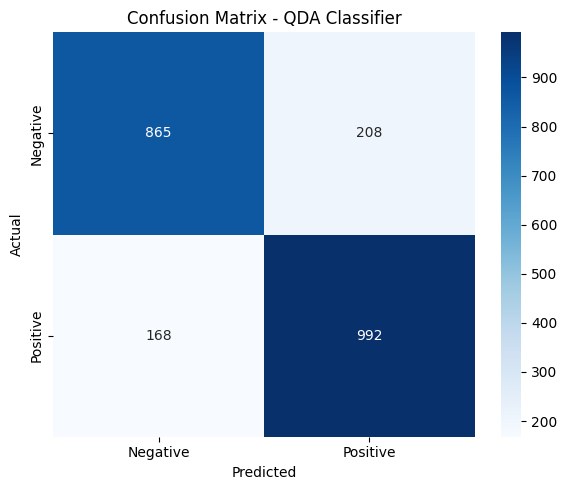

In [23]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

joblib.dump(qda, os.path.join(MODEL_DIR, "qda_classifier.pkl"))

y_pred_qda = qda.predict(X_test)
calculateMetrics("QDA Classifier", y_pred_qda, y_test)


## Linear Discriminant Analysis

LDA Classifier
Accuracy : 0.7573
Precision: 0.7572
Recall   : 0.7573
F1-score : 0.7572
----------------------------------------


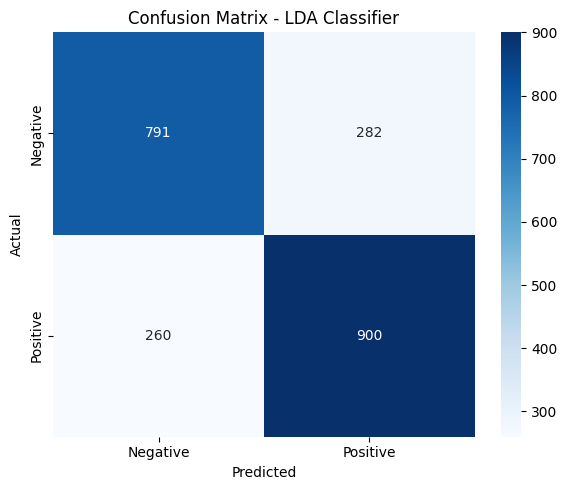

In [24]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

joblib.dump(lda, os.path.join(MODEL_DIR, "lda_classifier.pkl"))

y_pred_lda = lda.predict(X_test)
calculateMetrics("LDA Classifier", y_pred_lda, y_test)

## LGBM Classifier

[LightGBM] [Info] Number of positive: 4640, number of negative: 4291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045681 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 77227
[LightGBM] [Info] Number of data points in the train set: 8931, number of used features: 309
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


C:\Users\Pavani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Light GBM
Accuracy : 0.9601
Precision: 0.9601
Recall   : 0.9601
F1-score : 0.9601
----------------------------------------


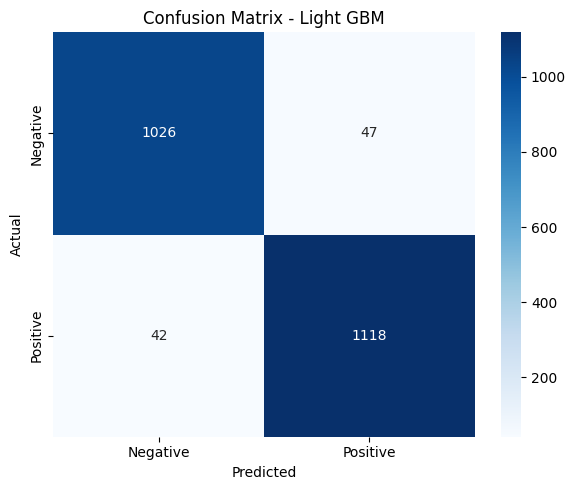

In [25]:
lgbm = LGBMClassifier(
    n_estimators=50,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=12,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.2,
    class_weight="balanced",
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
calculateMetrics("Light GBM", y_pred_lgbm, y_test)

C:\Users\Pavani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:864: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(


Adaptive Radius Neighbours
Accuracy : 0.9982
Precision: 0.9982
Recall   : 0.9982
F1-score : 0.9982
----------------------------------------


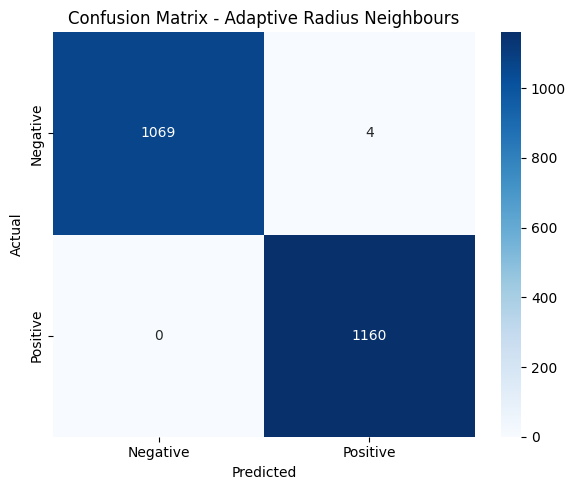

In [26]:

rnc = RadiusNeighborsClassifier(
    radius=2.5,
    weights="distance",
    metric="minkowski",
    p=2,
    outlier_label=-1
)

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski",
    p=2
)

rnc.fit(X_train, y_train)
knn.fit(X_train, y_train)

y_pred = rnc.predict(X_test)

# Replace outliers
outliers = y_pred == -1
y_pred[outliers] = knn.predict(X_test[outliers])

calculateMetrics("Adaptive Radius Neighbours", y_pred, y_test)

## Comparison Matrix

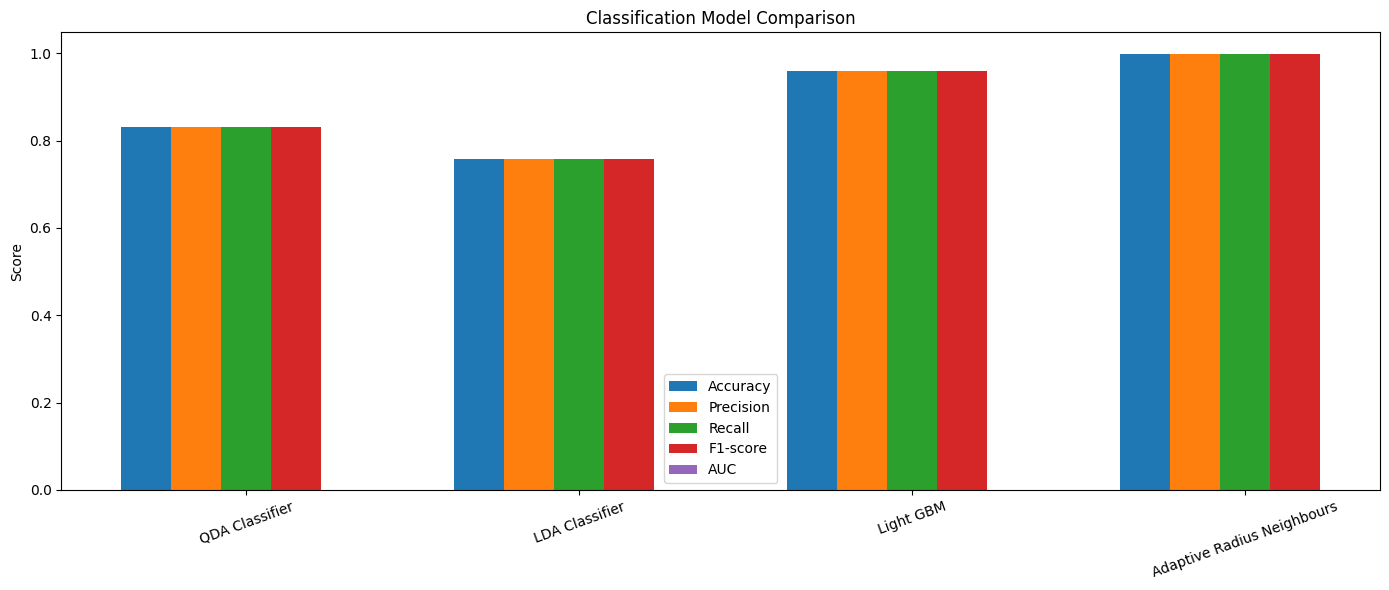

In [27]:
plot_classification_comparison()

## Prediction

In [28]:
test_df = pd.read_csv(r"dataset/test.csv")
test_df

,Text
0,is upset that he can't update his Facebook by ...
1,@Kenichan I dived many times for the ball. Man...
2,my whole body feels itchy and like its on fire
3,"@nationwideclass no, it's not behaving at all...."
4,@Kwesidei not the whole crew
5,Need a hug
6,@LOLTrish hey long time no see! Yes.. Rains a...
7,@Tatiana_K nope they didn't have it
8,@twittera que me muera ?
9,spring break in plain city... it's snowing


In [29]:
test_df.isnull().sum()

Text    0
dtype: int64

In [30]:
test_df["clean_tweet"] = test_df["Text"].progress_apply(preprocess_text_full)

Text Preprocessing: 100%|█████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 771.04it/s]


In [31]:
test_df.drop(columns=["Text"], inplace=True)

In [32]:
stat_features = test_df["clean_tweet"].progress_apply(extract_text_features)
stat_features.columns = [
    "word_count", "char_count", "avg_word_len", "std_word_len",
    "upper_words", "digit_words", "alpha_words",
    "unique_words", "lexical_diversity", "long_words"
]


Text Preprocessing: 100%|████████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 1698.48it/s]


In [33]:
X_text_test_df = vectorizer.transform(test_df["clean_tweet"])

In [34]:
X_text_svd_test1 = svd.transform(X_text_test_df)
X_text_svd_test = stdscaler.transform(X_text_svd_test1)

In [35]:
X_final_test = np.hstack([
    X_text_svd_test,
    stat_features.values
])

In [36]:
# Predict using Radius Neighbors
y_pred = rnc.predict(X_final_test)

# Identify outliers
outliers = (y_pred == -1)

# Replace only if outliers exist
if np.any(outliers):
    y_pred[outliers] = knn.predict(X_final_test[outliers])


In [37]:
results_df = test_df.copy()

results_df["Predicted_Label"] = np.where(
    y_pred == 0,
    "Negative",
    "Positive"
)
results_df

,clean_tweet,Predicted_Label
0,upset cant update facebook texting might cry r...,Negative
1,kenichan dive many time ball manage save 50 re...,Negative
2,whole body feel itchy like fire,Negative
3,nationwideclass behave im mad cant see,Negative
4,kwesidei whole crew,Negative
5,need hug,Negative
6,loltrish hey long time see yes rain bit bit lo...,Negative
7,tatiana k nope didnt,Negative
8,twittera que muera,Negative
9,spring break plain city snowing,Negative
